In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Ângulos em radianos
w_mg = 0.2366
w_ff = np.arctan(-1) + np.pi  # Corrigido para 2º quadrante

# Coordenadas
x_mg, y_mg = np.cos(w_mg), np.sin(w_mg)
x_ff, y_ff = np.cos(w_ff), np.sin(w_ff)

# Círculo
theta = np.linspace(0, 2 * np.pi, 500)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

# Setores até w_ff
theta_sector = np.linspace(0, w_ff, 200)
sector_x = np.cos(theta_sector)
sector_y = np.sin(theta_sector)

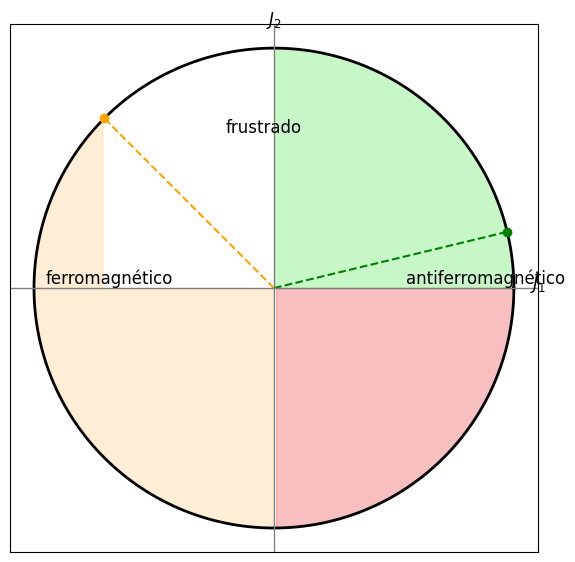

In [3]:
# Figura
fig, ax = plt.subplots(figsize=(6, 6))

# Preencher antiferromagnético (até w_ff)
ax.fill_betweenx(sector_y, 0, sector_x, where=(sector_x >= 0), color='lightgreen', alpha=0.5)

# Frustrado: entre w_ff e 3pi/2
ax.fill_between(circle_x, circle_y, where=(theta > w_ff) & (theta < 3*np.pi/2), color='navajowhite', alpha=0.5)

# Ferromagnético: resto
ax.fill_between(circle_x, circle_y, where=(theta >= 3*np.pi/2) | (theta < 0), color='lightcoral', alpha=0.5)

# Círculo
ax.plot(circle_x, circle_y, 'k', linewidth=2)

# Vetores
ax.plot([0, x_mg], [0, y_mg], 'g--', label=r'$w_{mg}$')
ax.plot([0, x_ff], [0, y_ff], 'orange', linestyle='--', label=r'$w_{ff}$')

# Pontos
ax.plot(x_mg, y_mg, 'go')
ax.plot(x_ff, y_ff, 'o', color='orange')

# Textos
ax.text(0.55, 0.02, 'antiferromagnético', fontsize=12)
ax.text(-0.95, 0.02, 'ferromagnético', fontsize=12)
ax.text(-0.2, 0.65, 'frustrado', fontsize=12)

# Eixos
ax.annotate(r'$J_1$', xy=(1.1, 0), fontsize=12, ha='center')
ax.annotate(r'$J_2$', xy=(0, 1.1), fontsize=12, ha='center')

# Estética
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(0, color='gray', linewidth=1)
ax.set_aspect('equal')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig("fig/diagrama_J1J2.png", dpi=300)
plt.show()